# 🎬 Regresión Lineal — ETL Películas OMDB
**Objetivo:** Predecir el `imdb_rating` usando variables numéricas originales + **features derivados** (feature engineering).

| Variable | Origen | Rol |
|---|---|---|
| `imdb_rating` | BD directa | 🎯 Variable objetivo (y) |
| `duracion` | BD directa | Feature base (x₁) |
| `anio` | BD directa | Feature base (x₂) |
| `recaudacion_log` | log₁₀(recaudacion) | Feature transformado (x₃) |
| `rec_por_min_log` | log₁₀(recaudacion/duracion) | ⭐ Feature derivado nuevo (x₄) |
| `es_drama`, `es_crime`… | genre dummies | ⭐ Features derivados nuevos (x₅…) |

In [2]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('OK Librerias importadas correctamente')
print(f'   pandas      {pd.__version__}')
print(f'   numpy       {np.__version__}')
print(f'   seaborn     {sns.__version__}')
print(f'   statsmodels {sm.__version__}')

OK Librerias importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


## Fase 2: Carga de datos desde PostgreSQL

In [3]:
# ── CELDA 2: Carga desde PostgreSQL ──────────────────────────
QUERY = """
SELECT
    p.titulo,
    r.anio,
    r.genero,
    r.director,
    r.imdb_rating,
    r.duracion,
    r.recaudacion,
    r.idioma,
    r.pais,
    r.fecha_extraccion
FROM registro_peliculas r
JOIN peliculas p ON r.pelicula_id = p.id
WHERE r.imdb_rating IS NOT NULL
  AND r.duracion    IS NOT NULL
  AND r.anio        IS NOT NULL
ORDER BY r.fecha_extraccion
"""

df_raw = pd.read_sql(QUERY, engine)

print(f'OK Datos cargados desde PostgreSQL')
print(f'   Filas    : {df_raw.shape[0]:,}')
print(f'   Columnas : {df_raw.shape[1]}')
df_raw.head(10)

OK Datos cargados desde PostgreSQL
   Filas    : 104
   Columnas : 10


,titulo,anio,genero,director,imdb_rating,duracion,recaudacion,idioma,pais,fecha_extraccion
0,Inception,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,8.8,148,292587330.0,"English, Japanese, French","United States, United Kingdom",2026-04-15 14:13:23.396596
1,Interstellar,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,8.7,169,203227580.0,English,"United States, United Kingdom, Canada",2026-04-15 14:13:24.858103
2,The Dark Knight,2008,"Action, Crime, Drama",Christopher Nolan,9.1,152,534987076.0,"English, Mandarin","United States, United Kingdom",2026-04-15 14:13:26.251749
3,Parasite,2019,"Drama, Thriller",Bong Joon Ho,8.5,132,53847897.0,"Korean, English",South Korea,2026-04-15 14:13:27.848542
4,Avatar,2009,"Action, Adventure, Fantasy",James Cameron,7.9,162,785221649.0,"English, Spanish","United States, United Kingdom",2026-04-15 14:13:30.383211
5,The Shawshank Redemption,1994,Drama,Frank Darabont,9.3,142,28767189.0,English,United States,2026-04-15 14:13:31.971855
6,The Godfather,1972,"Crime, Drama",Francis Ford Coppola,9.2,175,136381073.0,"English, Italian, Latin",United States,2026-04-15 14:13:33.442218
7,The Godfather Part II,1974,"Crime, Drama",Francis Ford Coppola,9.0,202,47834595.0,"English, Italian, Spanish, Latin, Sicilian",United States,2026-04-15 14:13:34.886828
8,Pulp Fiction,1994,"Crime, Drama",Quentin Tarantino,8.8,154,107928762.0,"English, Spanish, French",United States,2026-04-15 14:13:38.088050
9,Schindler's List,1993,"Biography, Drama, History",Steven Spielberg,9.0,195,96898818.0,"English, Hebrew, German, Polish, Latin",United States,2026-04-15 14:13:39.716335


In [4]:
# ── CELDA 3: Inspeccion del DataFrame ────────────────────────
print('=' * 50)
print('  INFORMACION GENERAL DEL DATASET')
print('=' * 50)
print(df_raw.info())
print('\nValores nulos por columna:')
print(df_raw.isnull().sum())
print(f'\nTotal de peliculas: {df_raw["titulo"].nunique()}')

  INFORMACION GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   titulo            104 non-null    object        
 1   anio              104 non-null    int64         
 2   genero            104 non-null    object        
 3   director          104 non-null    object        
 4   imdb_rating       104 non-null    float64       
 5   duracion          104 non-null    int64         
 6   recaudacion       99 non-null     float64       
 7   idioma            104 non-null    object        
 8   pais              104 non-null    object        
 9   fecha_extraccion  104 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 8.3+ KB
None

Valores nulos por columna:
titulo              0
anio                0
genero              0
director            0
imdb_rating

## Fase 3: Feature Engineering — Creacion de variables derivadas

Combinamos columnas existentes para crear nuevas con mayor poder predictivo:
- **rec_por_min** = recaudacion / duracion (sumar dos columnas como indica el profesor)
- **genre dummies** = columnas binarias por cada genero

In [5]:
# ── CELDA 4: Feature Engineering ─────────────────────────────
df = df_raw.dropna(subset=['imdb_rating', 'duracion', 'anio']).copy()

# Feature 1: log10(recaudacion) — normaliza la escala de millones
df['recaudacion_log'] = np.where(
    df['recaudacion'].notna() & (df['recaudacion'] > 0),
    np.log10(df['recaudacion']),
    np.nan
)

# Feature 2: recaudacion / duracion — eficiencia comercial por minuto (lo del profesor)
df['rec_por_min'] = np.where(
    df['recaudacion'].notna() & (df['duracion'] > 0),
    df['recaudacion'] / df['duracion'],
    np.nan
)
df['rec_por_min_log'] = np.where(
    df['rec_por_min'].notna() & (df['rec_por_min'] > 0),
    np.log10(df['rec_por_min']),
    np.nan
)

# Feature 3: dummies de genero
# 'Action, Drama, Thriller' se convierte en columnas binarias es_action, es_drama...
genre_dummies = (
    df['genero']
    .fillna('')
    .str.get_dummies(sep=', ')
)
genre_dummies.columns = [
    'es_' + col.lower().replace('-', '_').replace(' ', '_')
    for col in genre_dummies.columns
]
# Solo generos con al menos 5 peliculas
generos_validos = genre_dummies.columns[genre_dummies.sum() >= 5].tolist()
genre_dummies = genre_dummies[generos_validos]

df = pd.concat([df.reset_index(drop=True), genre_dummies.reset_index(drop=True)], axis=1)

print(f'OK Feature engineering completado')
print(f'   Filas en dataset limpio   : {len(df)}')
print(f'   Peliculas con rec_por_min : {df["rec_por_min"].notna().sum()}')
print(f'   Generos validos creados   : {len(generos_validos)}')
print(f'   Lista de generos          : {generos_validos}')
print(f'\nNuevas columnas derivadas:')
df[['titulo', 'duracion', 'recaudacion', 'rec_por_min', 'rec_por_min_log'] + generos_validos[:5]].head(8)

OK Feature engineering completado
   Filas en dataset limpio   : 104
   Peliculas con rec_por_min : 99
   Generos validos creados   : 13
   Lista de generos          : ['es_action', 'es_adventure', 'es_biography', 'es_comedy', 'es_crime', 'es_drama', 'es_horror', 'es_music', 'es_mystery', 'es_romance', 'es_sci_fi', 'es_thriller', 'es_war']

Nuevas columnas derivadas:


,titulo,duracion,recaudacion,rec_por_min,rec_por_min_log,es_action,es_adventure,es_biography,es_comedy,es_crime
0,Inception,148,292587330.0,1.976941e+06,6.295994,1,1,0,0,0
1,Interstellar,169,203227580.0,1.202530e+06,6.080096,0,1,0,0,0
2,The Dark Knight,152,534987076.0,3.519652e+06,6.546500,1,0,0,0,1
3,Parasite,132,53847897.0,4.079386e+05,5.610595,0,0,0,0,0
4,Avatar,162,785221649.0,4.847047e+06,6.685477,1,1,0,0,0
5,The Shawshank Redemption,142,28767189.0,2.025858e+05,5.306609,0,0,0,0,0
6,The Godfather,175,136381073.0,7.793204e+05,5.891716,0,0,0,0,1
7,The Godfather Part II,202,47834595.0,2.368049e+05,5.374391,0,0,0,0,1


## Fase 4: EDA — Analisis Exploratorio de Datos

In [6]:
# ── CELDA 5: Estadisticas descriptivas ───────────────────────
vars_num = ['imdb_rating', 'duracion', 'anio', 'recaudacion_log', 'rec_por_min_log']
desc = df[vars_num].describe().round(2)
print('ESTADISTICAS DESCRIPTIVAS')
print(desc)

ESTADISTICAS DESCRIPTIVAS
       imdb_rating  duracion     anio  recaudacion_log  rec_por_min_log
count       104.00    104.00   104.00            99.00            99.00
mean          8.29    137.36  1992.55             7.78             5.65
std           0.44     33.74    18.00             0.66             0.64
min           6.70     30.00  1942.00             4.82             2.69
25%           8.10    114.75  1981.75             7.49             5.40
50%           8.30    132.00  1996.50             7.87             5.69
75%           8.50    158.25  2006.00             8.20             6.08
max           9.30    229.00  2019.00             8.93             6.69


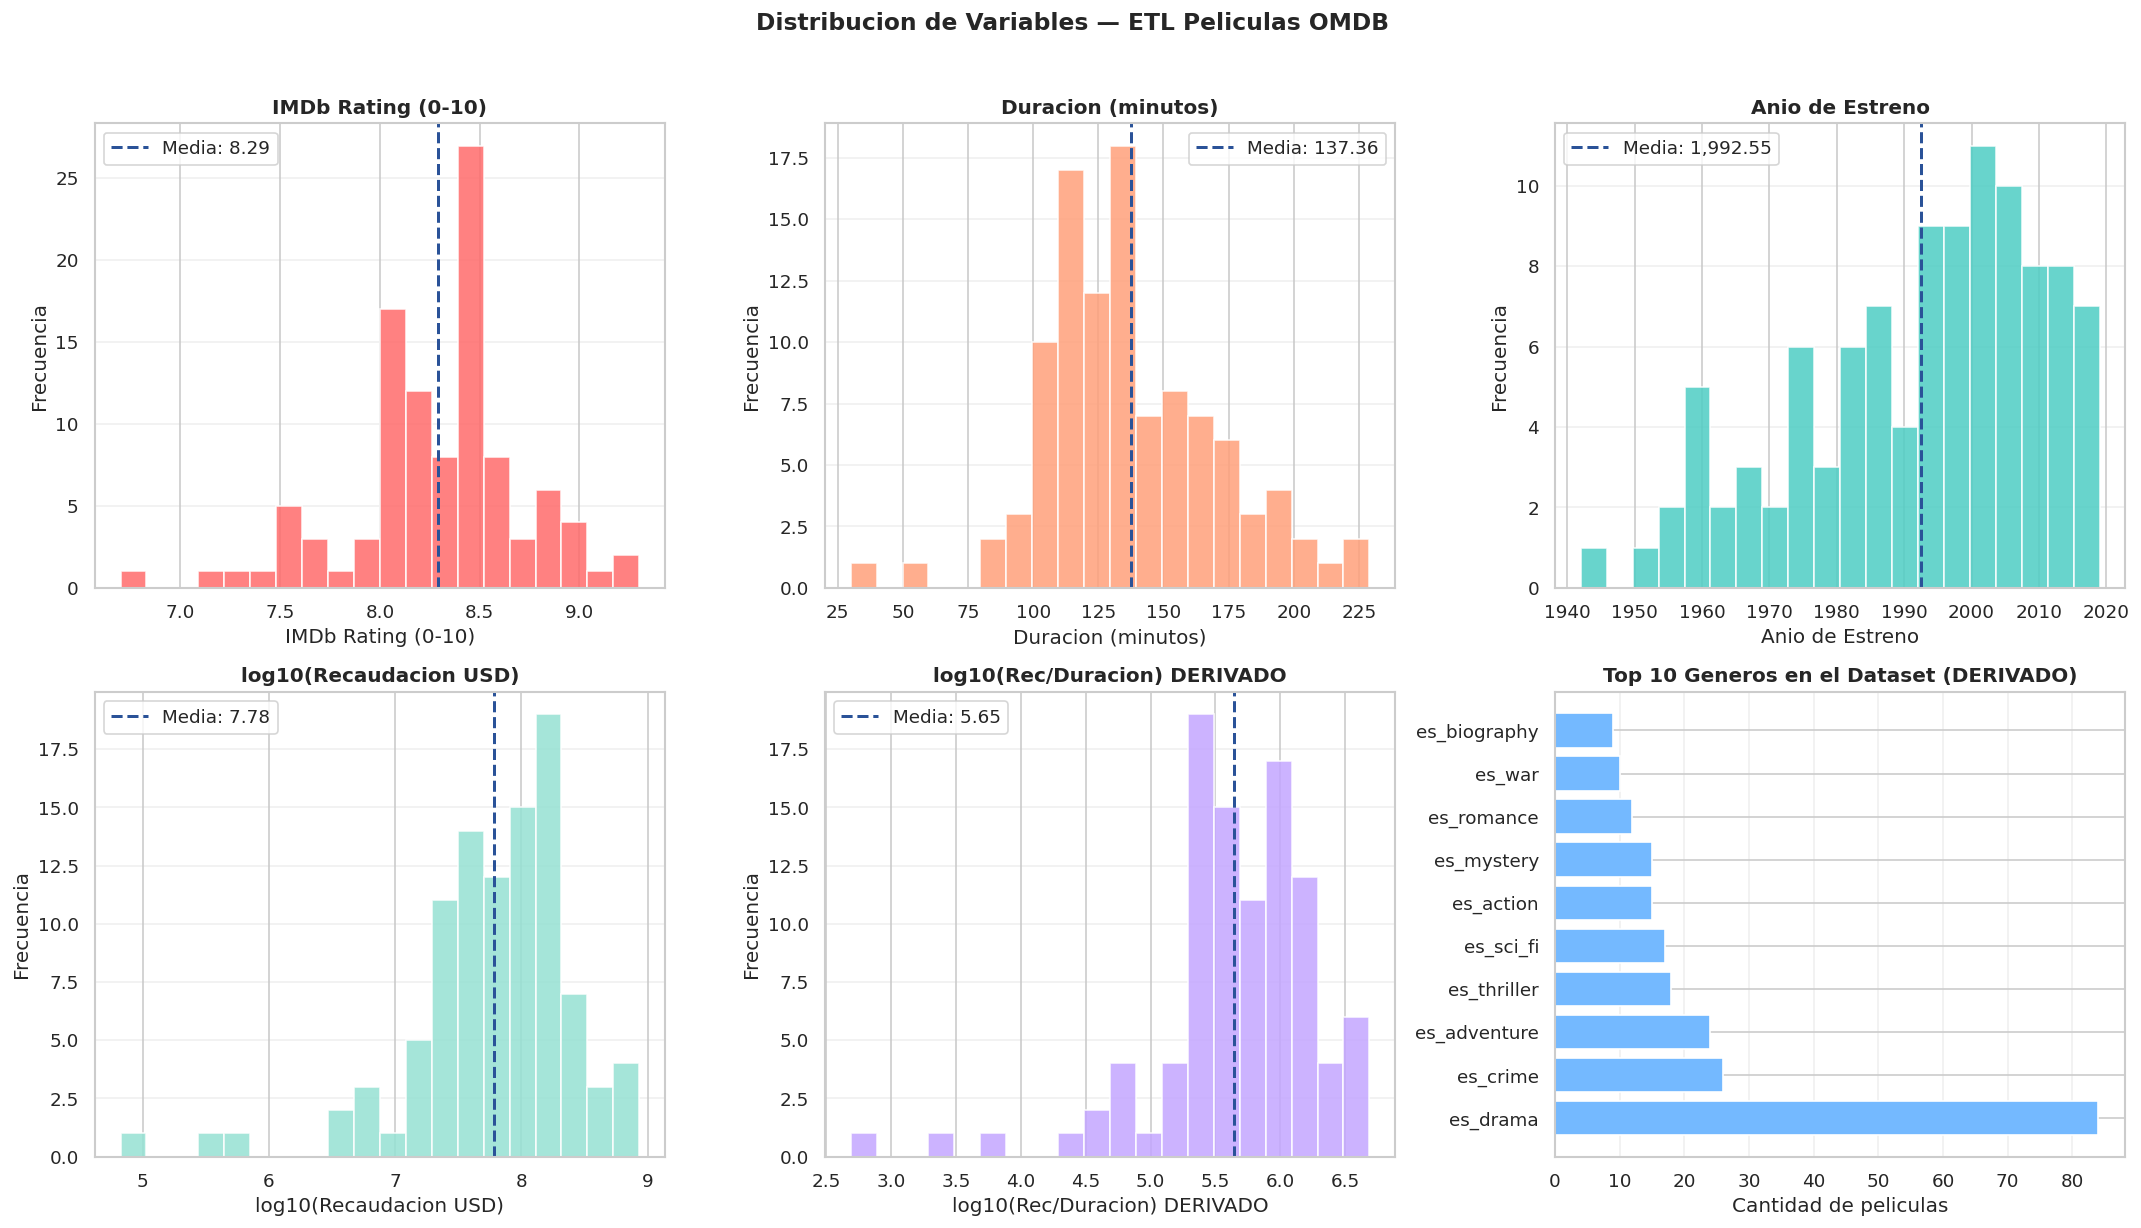

OK Guardado en data/graficas/eda_distribuciones.png


In [7]:
# ── CELDA 6: Histogramas de distribucion ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribucion de Variables — ETL Peliculas OMDB',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'imdb_rating':     ('IMDb Rating (0-10)',            '#ff6b6b'),
    'duracion':        ('Duracion (minutos)',             '#ffa07a'),
    'anio':            ('Anio de Estreno',                '#4ecdc4'),
    'recaudacion_log': ('log10(Recaudacion USD)',         '#95e1d3'),
    'rec_por_min_log': ('log10(Rec/Duracion) DERIVADO',  '#c3a6ff'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    data_col = df[col].dropna()
    ax.hist(data_col, bins=20, color=color, edgecolor='white', alpha=0.85)
    media = data_col.mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:,.2f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Ultima celda: conteo por genero
ax_g = axes.flat[5]
conteo = genre_dummies[generos_validos].sum().sort_values(ascending=False).head(10)
ax_g.barh(conteo.index, conteo.values, color='#74b9ff', edgecolor='white')
ax_g.set_title('Top 10 Generos en el Dataset (DERIVADO)', fontweight='bold')
ax_g.set_xlabel('Cantidad de peliculas')
ax_g.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK Guardado en data/graficas/eda_distribuciones.png')

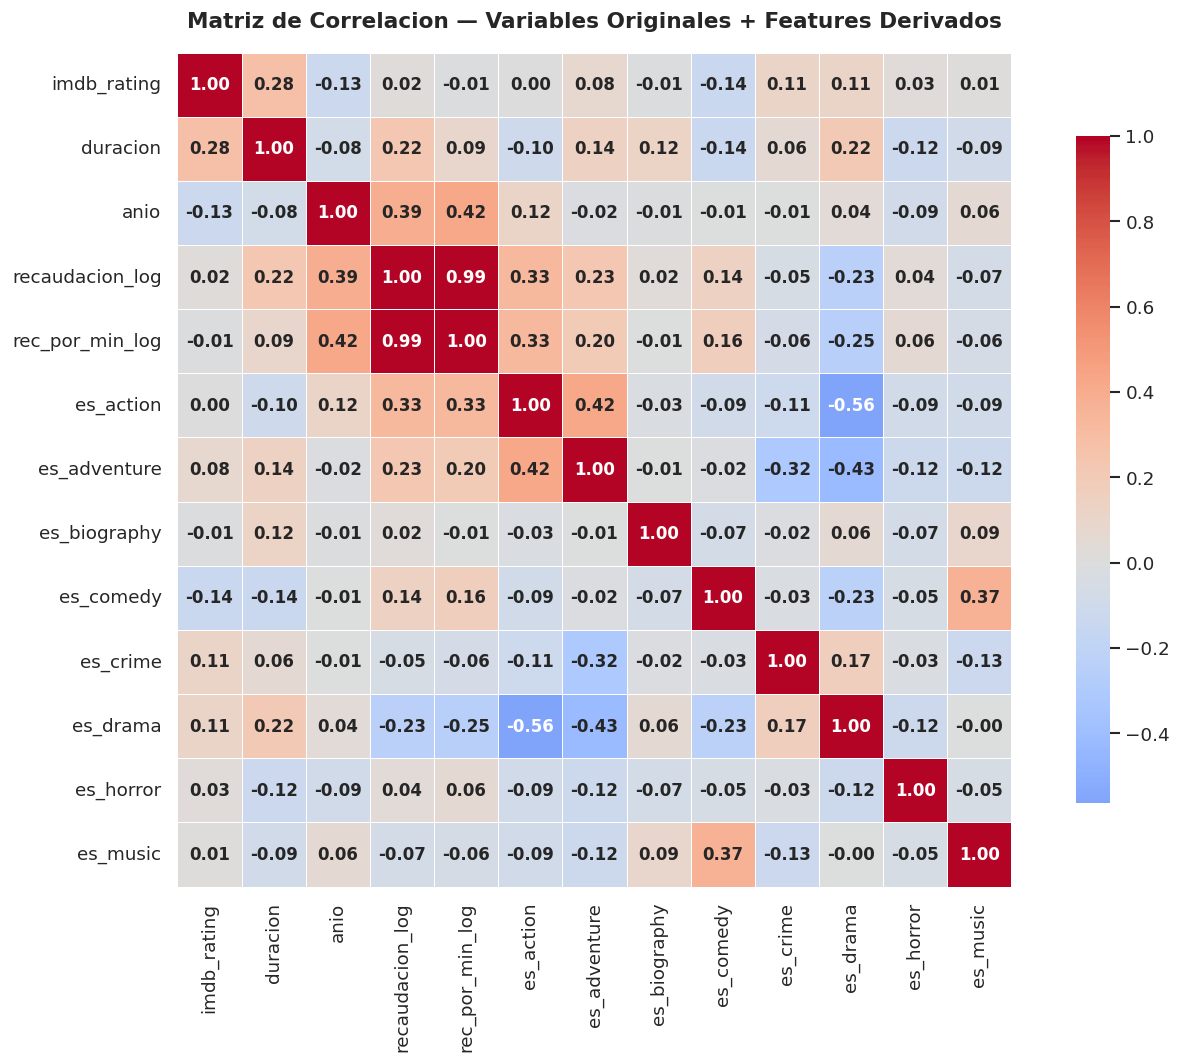


Correlacion con imdb_rating (TODAS las variables, ordenada):
duracion           0.2784
es_crime           0.1119
es_drama           0.1088
es_adventure       0.0776
es_horror          0.0349
es_sci_fi          0.0316
recaudacion_log    0.0215
es_music           0.0143
es_action          0.0010
es_biography      -0.0102
rec_por_min_log   -0.0132
es_mystery        -0.0492
es_war            -0.0540
anio              -0.1273
es_romance        -0.1315
es_comedy         -0.1402
es_thriller       -0.2074


In [8]:
# ── CELDA 7: Matriz de correlacion CON features derivados ────
vars_corr = ['imdb_rating', 'duracion', 'anio', 'recaudacion_log', 'rec_por_min_log'] + generos_validos
corr = df[vars_corr].corr()

vars_heatmap = ['imdb_rating', 'duracion', 'anio', 'recaudacion_log', 'rec_por_min_log'] + generos_validos[:8]
corr_heatmap = df[vars_heatmap].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_heatmap, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title('Matriz de Correlacion — Variables Originales + Features Derivados',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelacion con imdb_rating (TODAS las variables, ordenada):')
corr_target = corr['imdb_rating'].drop('imdb_rating').sort_values(ascending=False)
print(corr_target.round(4).to_string())

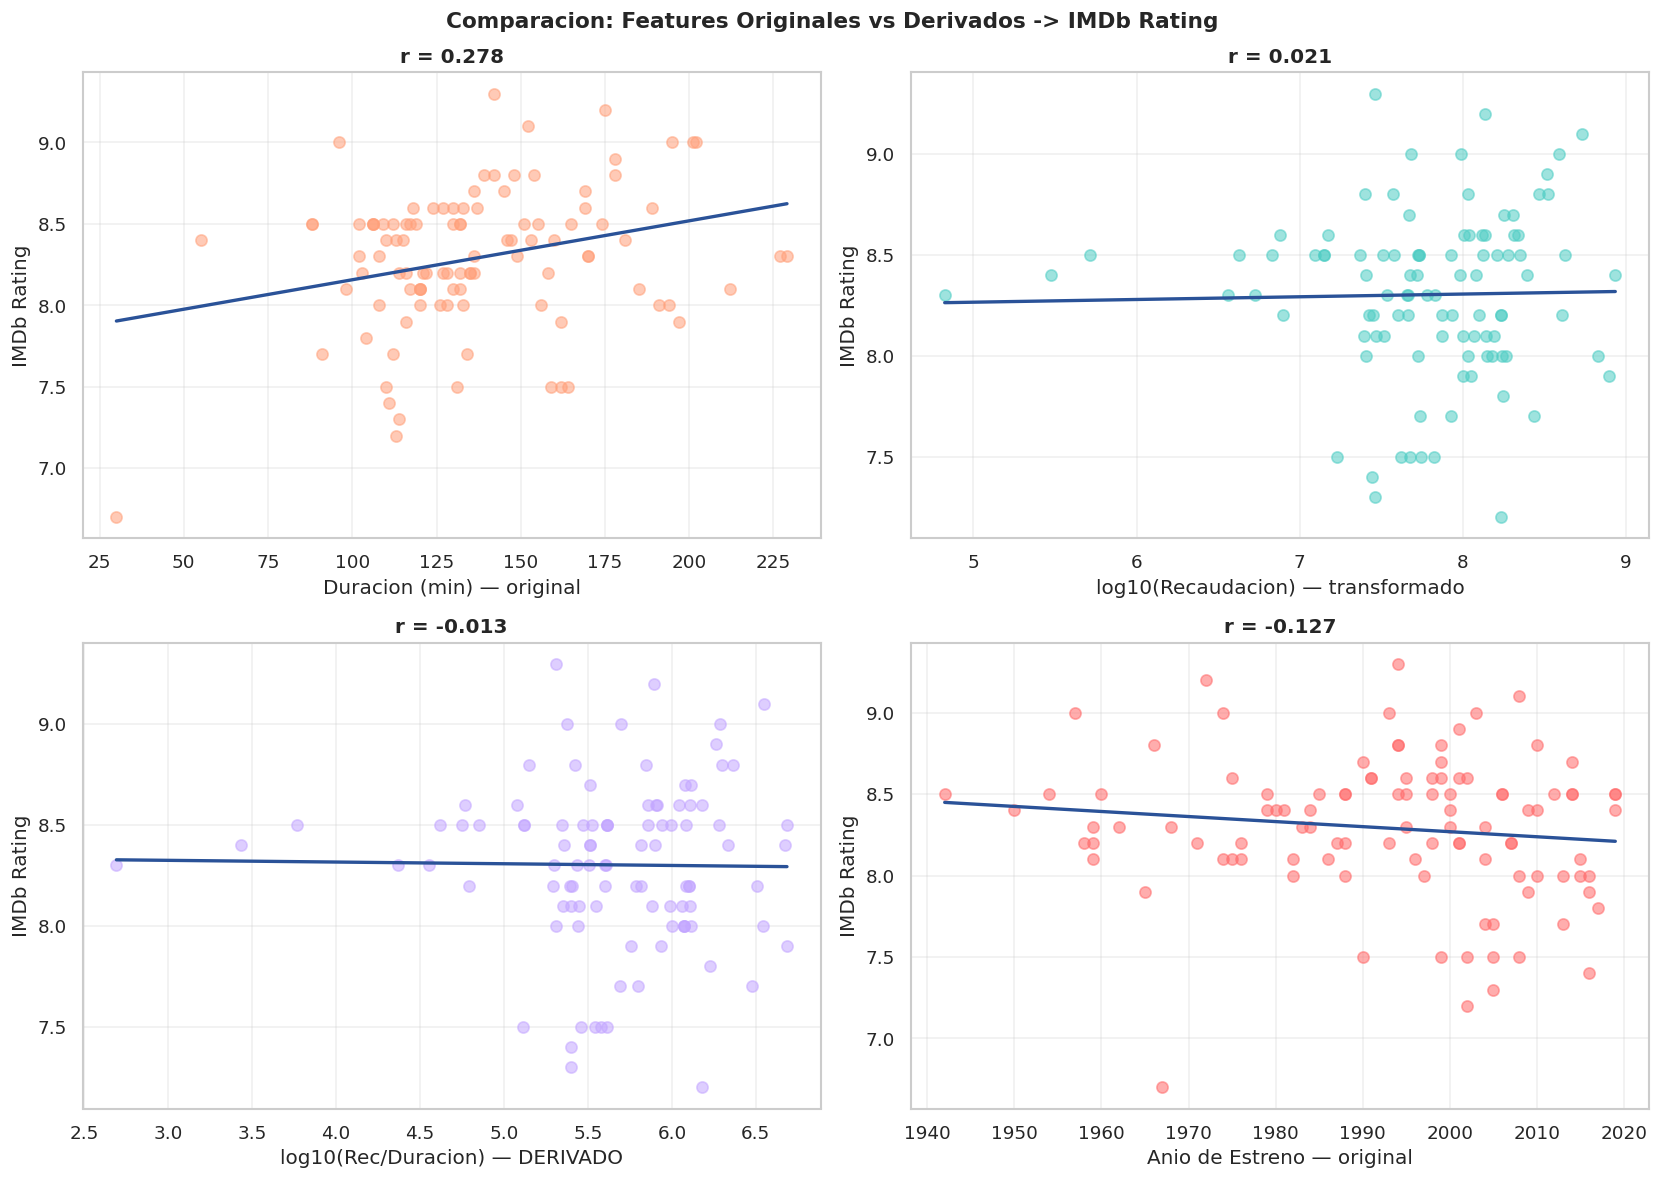

In [9]:
# ── CELDA 8: Scatter plots — originales vs derivados ─────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparacion: Features Originales vs Derivados -> IMDb Rating',
             fontsize=13, fontweight='bold')

pares = [
    ('duracion',        'Duracion (min) — original',           '#ffa07a'),
    ('recaudacion_log', 'log10(Recaudacion) — transformado',   '#4ecdc4'),
    ('rec_por_min_log', 'log10(Rec/Duracion) — DERIVADO',      '#c3a6ff'),
    ('anio',            'Anio de Estreno — original',          '#ff6b6b'),
]

for ax, (feature, xlabel, color) in zip(axes.flat, pares):
    data_feat = df[[feature, 'imdb_rating']].dropna()
    ax.scatter(data_feat[feature], data_feat['imdb_rating'],
               alpha=0.55, s=45, color=color)
    z = np.polyfit(data_feat[feature], data_feat['imdb_rating'], 1)
    p = np.poly1d(z)
    xp = np.linspace(data_feat[feature].min(), data_feat[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = data_feat[[feature, 'imdb_rating']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('IMDb Rating')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

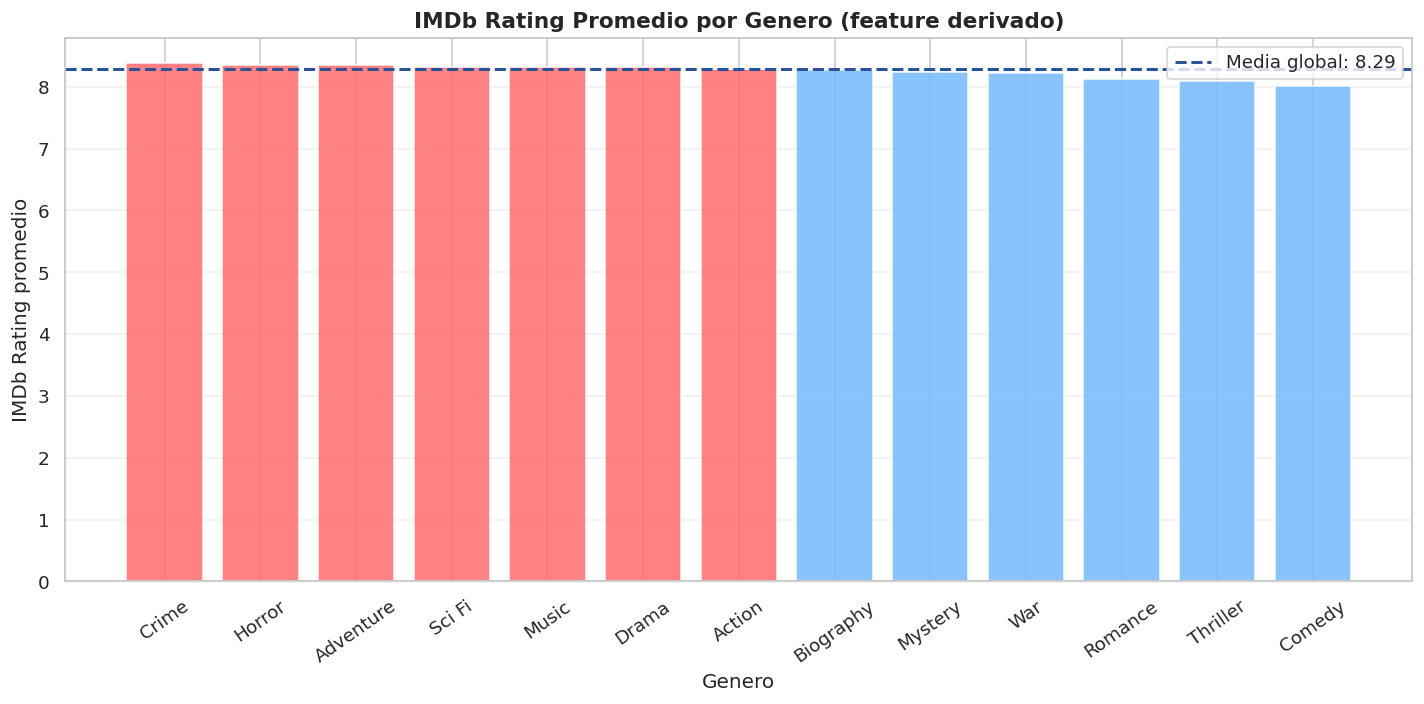


Rating promedio por genero (descendente):
Crime        8.377
Horror       8.360
Adventure    8.354
Sci Fi       8.324
Music        8.320
Drama        8.315
Action       8.293
Biography    8.278
Mystery      8.240
War          8.220
Romance      8.133
Thriller     8.094
Comedy       8.020


In [10]:
# ── CELDA 9: IMDb Rating promedio por genero ──────────────────
ratings_por_genero = {}
for col in generos_validos:
    nombre = col.replace('es_', '').replace('_', ' ').title()
    ratings_por_genero[nombre] = df[df[col] == 1]['imdb_rating'].mean()

rg = pd.Series(ratings_por_genero).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#ff6b6b' if v >= df['imdb_rating'].mean() else '#74b9ff' for v in rg.values]
ax.bar(rg.index, rg.values, color=colors, edgecolor='white', alpha=0.85)
ax.axhline(df['imdb_rating'].mean(), color='#2a5298', linestyle='--',
           linewidth=1.8, label=f'Media global: {df["imdb_rating"].mean():.2f}')
ax.set_xlabel('Genero')
ax.set_ylabel('IMDb Rating promedio')
ax.set_title('IMDb Rating Promedio por Genero (feature derivado)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/rating_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRating promedio por genero (descendente):')
print(rg.round(3).to_string())

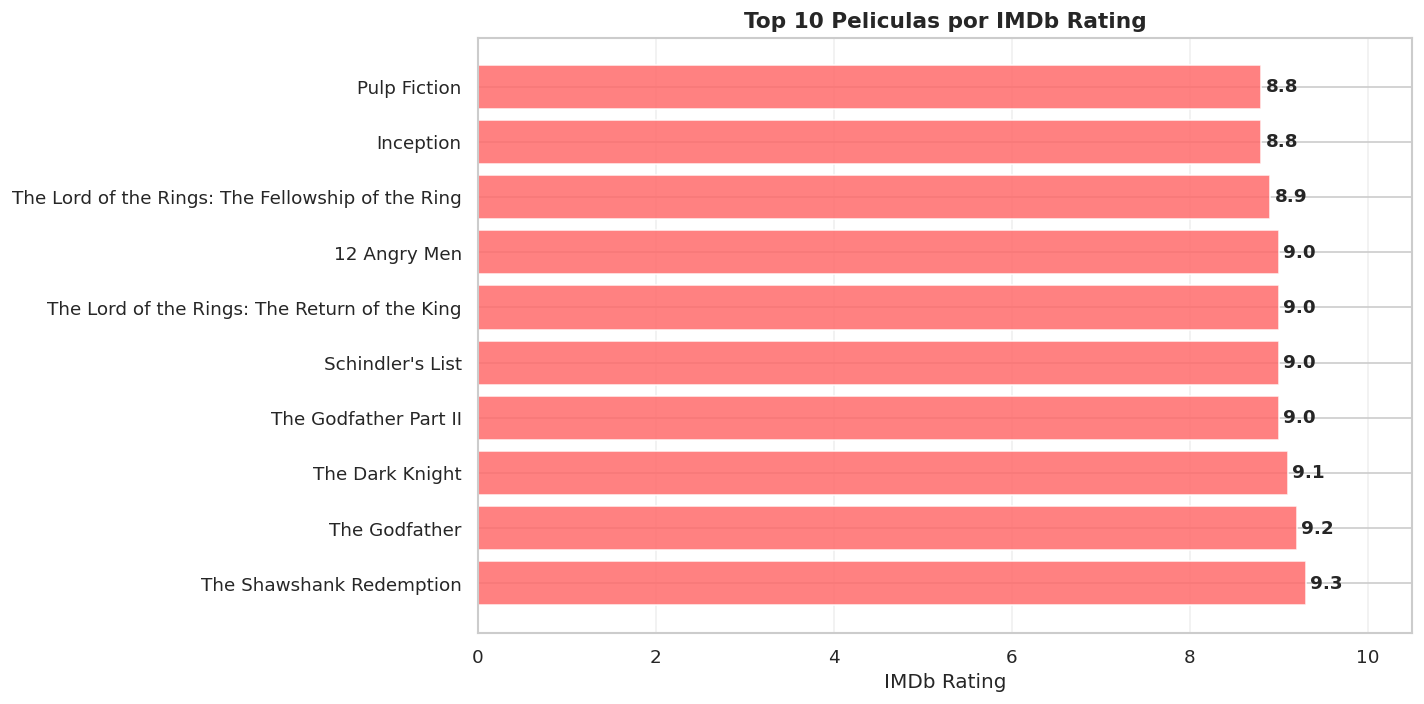

In [11]:
# ── CELDA 10: Top 10 peliculas por IMDb Rating ────────────────
fig, ax = plt.subplots(figsize=(12, 6))
top10 = df.nlargest(10, 'imdb_rating')[['titulo', 'imdb_rating', 'anio']].reset_index(drop=True)

bars = ax.barh(top10['titulo'], top10['imdb_rating'],
               color='#ff6b6b', edgecolor='white', alpha=0.85)
ax.set_xlabel('IMDb Rating', fontsize=12)
ax.set_title('Top 10 Peliculas por IMDb Rating', fontsize=13, fontweight='bold')
ax.set_xlim(0, 10.5)
for bar, val in zip(bars, top10['imdb_rating']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/top10_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## Fase 5: Regresion Lineal Simple
**Predictor:** `rec_por_min_log` — el feature derivado (recaudacion / duracion)

```
y_hat = B0 + B1 * log10(recaudacion/duracion) + error
```

In [12]:
# ── CELDA 11: Split Train / Test ─────────────────────────────
df_simple = df[['rec_por_min_log', 'imdb_rating']].dropna()

X_simple = df_simple[['rec_por_min_log']].values
y        = df_simple['imdb_rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f'Dataset para modelo simple: {len(df_simple)} filas')
print(f'Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)')

Dataset para modelo simple: 99 filas
Train: 79 muestras (80%)
Test : 20 muestras  (20%)


In [13]:
# ── CELDA 12: Entrenamiento con scikit-learn ──────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f'Intercepto  B0 : {modelo_simple.intercept_:.4f}')
print(f'Coeficiente B1 : {modelo_simple.coef_[0]:.6f}')
print(f'\nEcuacion: imdb_rating = {modelo_simple.intercept_:.3f}'
      f' + {modelo_simple.coef_[0]:.4f} x log10(recaudacion/duracion)')

Intercepto  B0 : 8.4074
Coeficiente B1 : -0.020613

Ecuacion: imdb_rating = 8.407 + -0.0206 x log10(recaudacion/duracion)


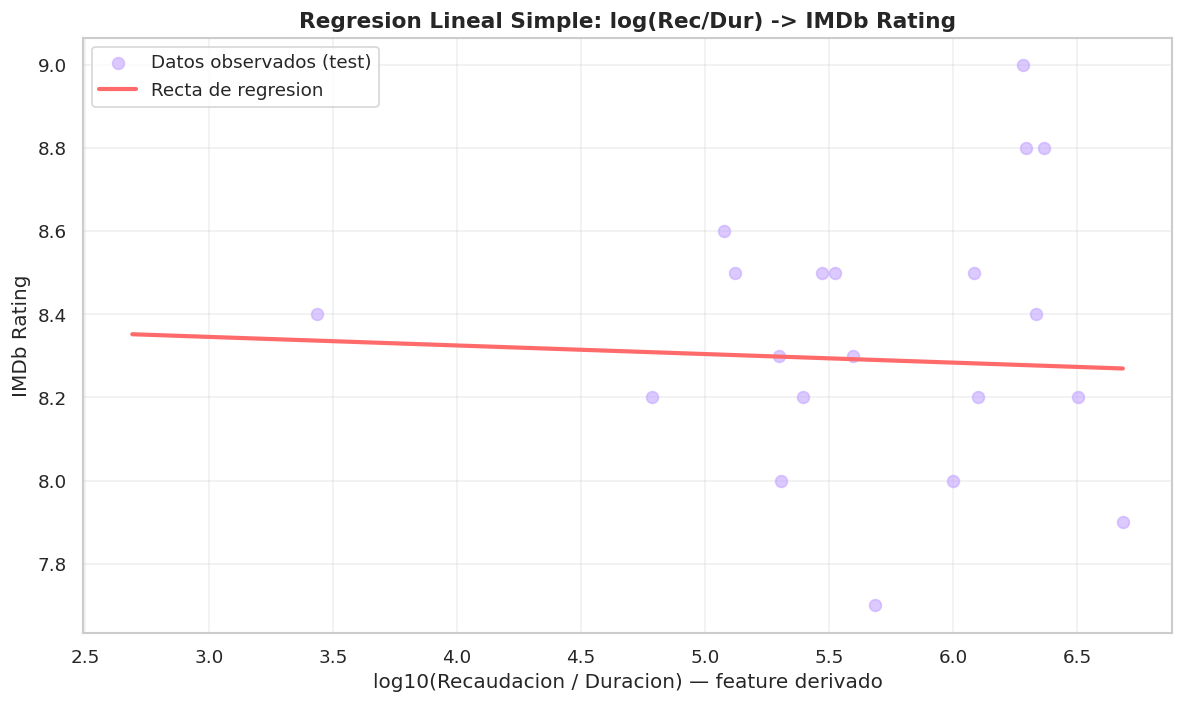

In [14]:
# ── CELDA 13: Recta de regresion ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.6, s=50,
           color='#c3a6ff', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresion')

ax.set_xlabel('log10(Recaudacion / Duracion) — feature derivado', fontsize=12)
ax.set_ylabel('IMDb Rating', fontsize=12)
ax.set_title('Regresion Lineal Simple: log(Rec/Dur) -> IMDb Rating',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── CELDA 14: Metricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print('=' * 54)
print('    METRICAS — REGRESION LINEAL SIMPLE')
print('    Feature: log10(recaudacion / duracion)')
print('=' * 54)
print(f'  R2   (coef. determinacion)   : {r2:.4f}  ({r2*100:.2f}%)')
print(f'  MSE  (error cuadratico med)  : {mse:.4f}')
print(f'  RMSE (raiz del MSE)          : {rmse:.4f}')
print(f'  MAE  (error absoluto medio)  : {mae:.4f}')
print('=' * 54)

    METRICAS — REGRESION LINEAL SIMPLE
    Feature: log10(recaudacion / duracion)
  R2   (coef. determinacion)   : -0.0437  (-4.37%)
  MSE  (error cuadratico med)  : 0.1018
  RMSE (raiz del MSE)          : 0.3190
  MAE  (error absoluto medio)  : 0.2496


In [16]:
# ── CELDA 15: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df_simple['rec_por_min_log'])
modelo_ols_simple = sm.OLS(df_simple['imdb_rating'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.01681
Date:                Fri, 17 Apr 2026   Prob (F-statistic):              0.897
Time:                        08:58:02   Log-Likelihood:                -52.398
No. Observations:                  99   AIC:                             108.8
Df Residuals:                      97   BIC:                             114.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.3508      0.371     

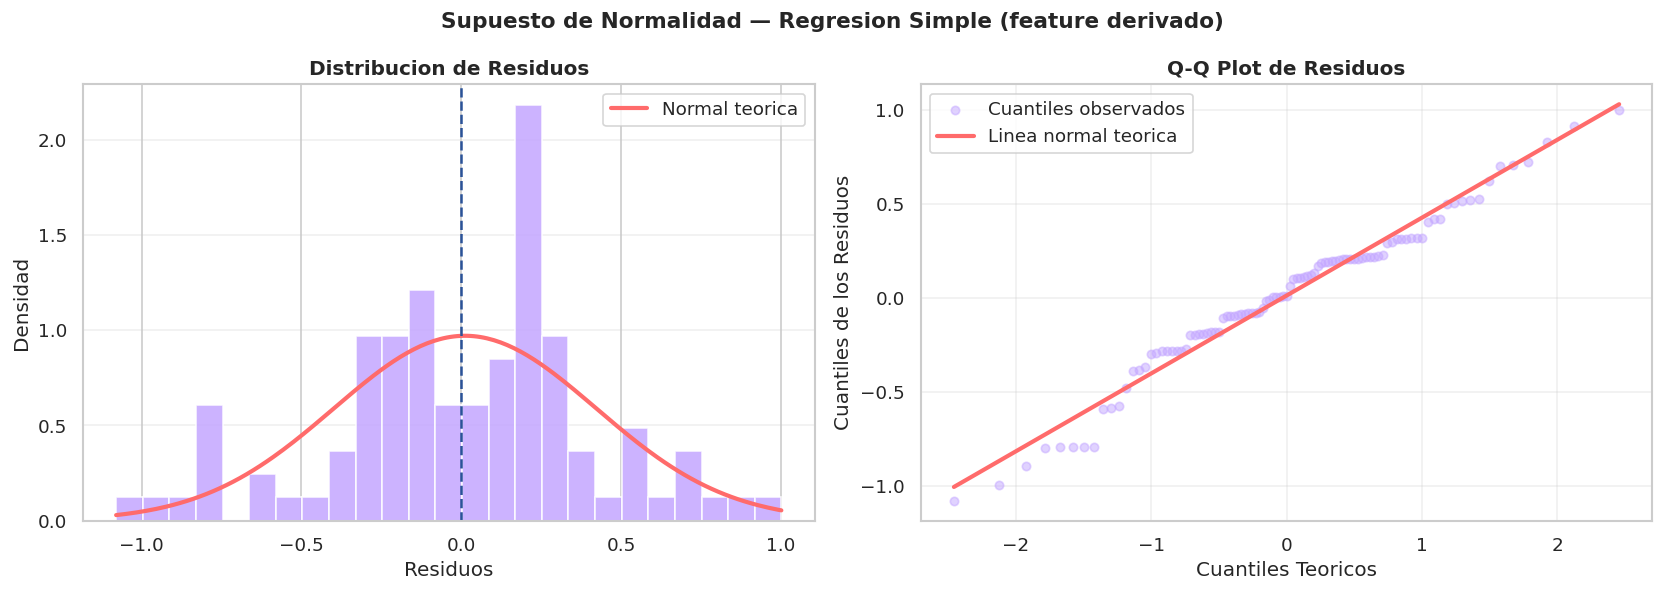


Test de Shapiro-Wilk:
   Estadistico W : 0.9768
   p-value       : 0.078023
   Conclusion    : OK No se rechaza normalidad (p > 0.05)


In [17]:
# ── CELDA 16: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df_simple[['rec_por_min_log']].values)
residuos   = df_simple['imdb_rating'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresion Simple (feature derivado)',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=25, color='#c3a6ff', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teorica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribucion de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.5, s=25, color='#c3a6ff',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Linea normal teorica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teoricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f'\nTest de Shapiro-Wilk:')
print(f'   Estadistico W : {stat_sw:.4f}')
print(f'   p-value       : {p_sw:.6f}')
if p_sw > 0.05:
    print('   Conclusion    : OK No se rechaza normalidad (p > 0.05)')
else:
    print('   Conclusion    : AVISO Se rechaza normalidad (p <= 0.05)')

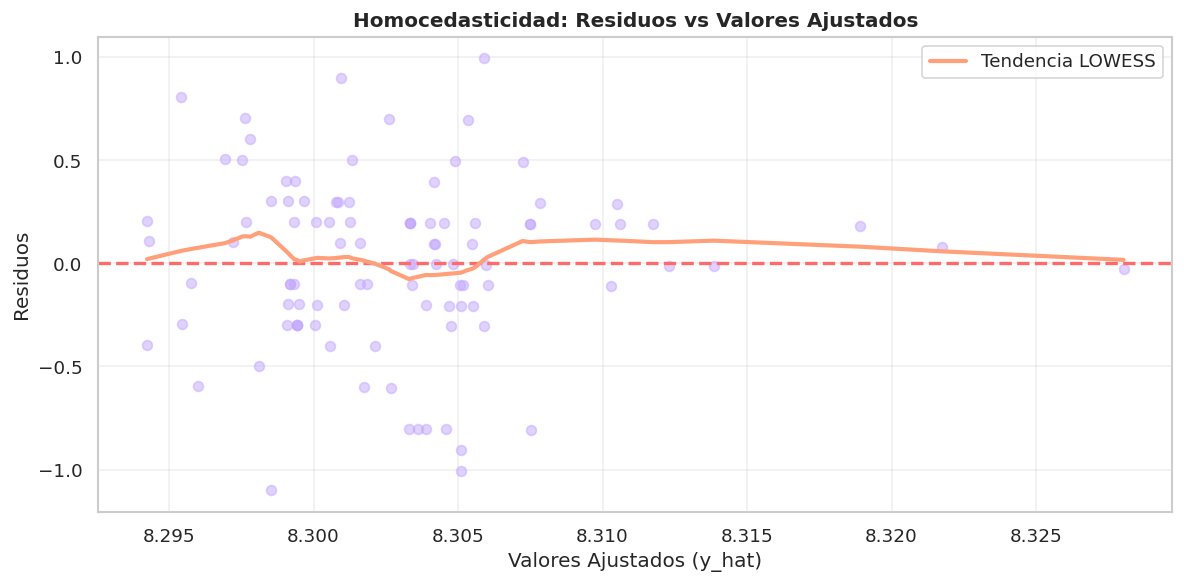


Test de Breusch-Pagan (Homocedasticidad):
   Estadistico LM : 1.1913
   p-value        : 0.275065
   Conclusion     : OK Homocedasticidad (p > 0.05)


In [18]:
# ── CELDA 17: Homocedasticidad (modelo simple) ───────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.5, s=35, color='#c3a6ff')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.4)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (y_hat)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png', dpi=150, bbox_inches='tight')
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)
print(f'\nTest de Breusch-Pagan (Homocedasticidad):')
print(f'   Estadistico LM : {lm:.4f}')
print(f'   p-value        : {lm_p:.6f}')
if lm_p > 0.05:
    print('   Conclusion     : OK Homocedasticidad (p > 0.05)')
else:
    print('   Conclusion     : AVISO Heterocedasticidad detectada (p <= 0.05)')

## Fase 6: Regresion Lineal Multiple con Features Derivados

Combinamos `rec_por_min_log`, `duracion`, `anio` y los **dummies de genero** con mayor correlacion.

```
y_hat = B0 + B1*rec_por_min_log + B2*duracion + B3*anio + B4*es_drama + B5*es_crime + ... + error
```

In [19]:
# ── CELDA 18: Seleccion de features para modelo multiple ─────
corr_generos = df[generos_validos + ['imdb_rating']].corr()['imdb_rating'].drop('imdb_rating')
top_generos = corr_generos.abs().sort_values(ascending=False).head(5).index.tolist()

print('Top 5 generos por correlacion con imdb_rating:')
print(corr_generos[top_generos].round(4).to_string())

FEATURES = ['rec_por_min_log', 'duracion', 'anio'] + top_generos
print(f'\nOK Features seleccionados para modelo multiple:')
for f in FEATURES:
    print(f'   - {f}')

Top 5 generos por correlacion con imdb_rating:
es_thriller   -0.2074
es_comedy     -0.1402
es_romance    -0.1315
es_crime       0.1119
es_drama       0.1088

OK Features seleccionados para modelo multiple:
   - rec_por_min_log
   - duracion
   - anio
   - es_thriller
   - es_comedy
   - es_romance
   - es_crime
   - es_drama


In [20]:
# ── CELDA 19: Entrenamiento modelo multiple ───────────────────
df_multi = df[FEATURES + ['imdb_rating']].dropna()
print(f'Filas disponibles para modelo multiple: {len(df_multi)}')

X_multi = df_multi[FEATURES].values
y_m     = df_multi['imdb_rating'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_m, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

print(f'\nIntercepto  B0 : {modelo_multi.intercept_:.4f}')
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f'Coeficiente {feat:>22} : {coef:.6f}')

Filas disponibles para modelo multiple: 99

Intercepto  B0 : 16.6647
Coeficiente        rec_por_min_log : 0.054522
Coeficiente               duracion : 0.001690
Coeficiente                   anio : -0.004463
Coeficiente            es_thriller : -0.234561
Coeficiente              es_comedy : -0.346843
Coeficiente             es_romance : -0.356152
Coeficiente               es_crime : 0.097740
Coeficiente               es_drama : 0.060703


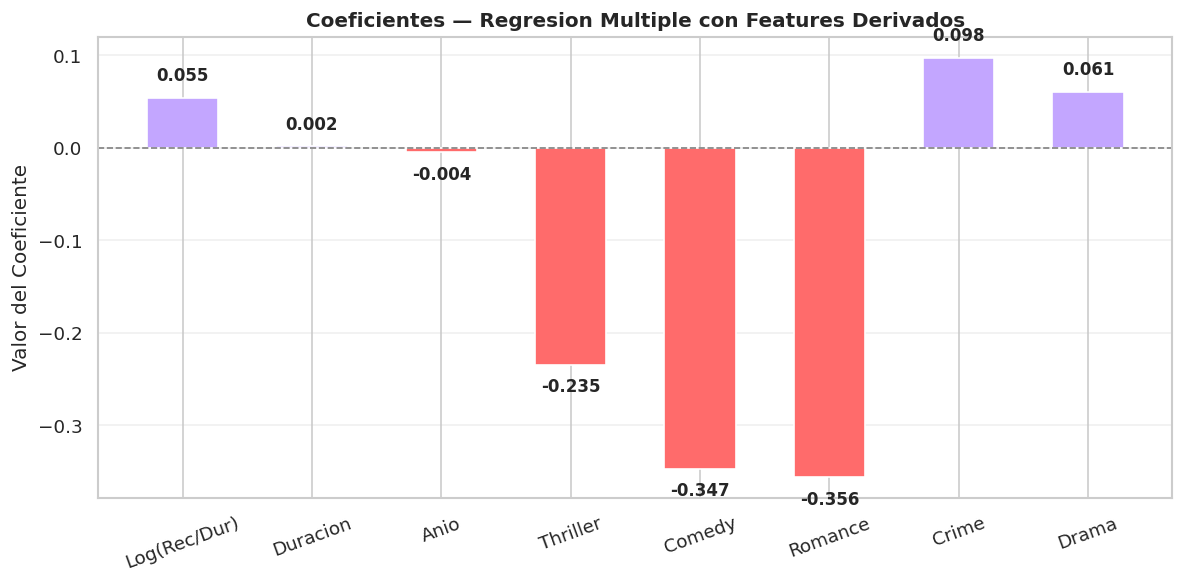

In [21]:
# ── CELDA 20: Grafica de coeficientes ────────────────────────
labels_feat = [f.replace('rec_por_min_log', 'log(Rec/Dur)')
                .replace('es_', '').replace('_', ' ').title()
               for f in FEATURES]
colores = ['#c3a6ff' if c > 0 else '#ff6b6b' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_feat, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.55)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresion Multiple con Features Derivados',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
ax.tick_params(axis='x', rotation=20)

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = max(abs(modelo_multi.coef_)) * 0.04
    va = 'bottom' if coef >= 0 else 'top'
    y_pos = bar.get_height() + (offset if coef >= 0 else -offset)
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
            f'{coef:.3f}', ha='center', va=va,
            fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── CELDA 21: Metricas modelo multiple ───────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print('=' * 54)
print('  METRICAS — REGRESION LINEAL MULTIPLE')
print('  Features: rec_por_min_log + duracion + anio + generos')
print('=' * 54)
print(f'  R2   (coef. determinacion)   : {r2_m:.4f}  ({r2_m*100:.2f}%)')
print(f'  MSE  (error cuadratico med)  : {mse_m:.4f}')
print(f'  RMSE (raiz del MSE)          : {rmse_m:.4f}')
print(f'  MAE  (error absoluto medio)  : {mae_m:.4f}')
print('=' * 54)

  METRICAS — REGRESION LINEAL MULTIPLE
  Features: rec_por_min_log + duracion + anio + generos
  R2   (coef. determinacion)   : -0.1530  (-15.30%)
  MSE  (error cuadratico med)  : 0.1124
  RMSE (raiz del MSE)          : 0.3353
  MAE  (error absoluto medio)  : 0.2725


In [23]:
# ── CELDA 22: OLS statsmodels — modelo multiple ──────────────
X_ols_m = sm.add_constant(df_multi[FEATURES])
modelo_ols_multi = sm.OLS(df_multi['imdb_rating'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     2.365
Date:                Fri, 17 Apr 2026   Prob (F-statistic):             0.0233
Time:                        08:58:10   Log-Likelihood:                -42.962
No. Observations:                  99   AIC:                             103.9
Df Residuals:                      90   BIC:                             127.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              15.7988      5.083     

In [24]:
# ── CELDA 23: VIF — Factor de Inflacion de la Varianza ───────
X_vif = df_multi[FEATURES].copy()

vif_data = pd.DataFrame({
    'Variable': FEATURES,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data['VIF'] = vif_data['VIF'].round(3)
vif_data['Criterio'] = vif_data['VIF'].apply(
    lambda v: 'OK Sin multicolinealidad (VIF < 5)'
              if v < 5
              else ('AVISO Moderada (5 <= VIF < 10)'
                    if v < 10
                    else 'ERROR Severa (VIF >= 10)')
)

print('\nFACTOR DE INFLACION DE LA VARIANZA (VIF)')
print('=' * 65)
print(vif_data.to_string(index=False))
print('=' * 65)


FACTOR DE INFLACION DE LA VARIANZA (VIF)
       Variable     VIF                           Criterio
rec_por_min_log  93.807           ERROR Severa (VIF >= 10)
       duracion  23.728           ERROR Severa (VIF >= 10)
           anio 119.280           ERROR Severa (VIF >= 10)
    es_thriller   1.322 OK Sin multicolinealidad (VIF < 5)
      es_comedy   1.151 OK Sin multicolinealidad (VIF < 5)
     es_romance   1.169 OK Sin multicolinealidad (VIF < 5)
       es_crime   1.402 OK Sin multicolinealidad (VIF < 5)
       es_drama   6.637     AVISO Moderada (5 <= VIF < 10)


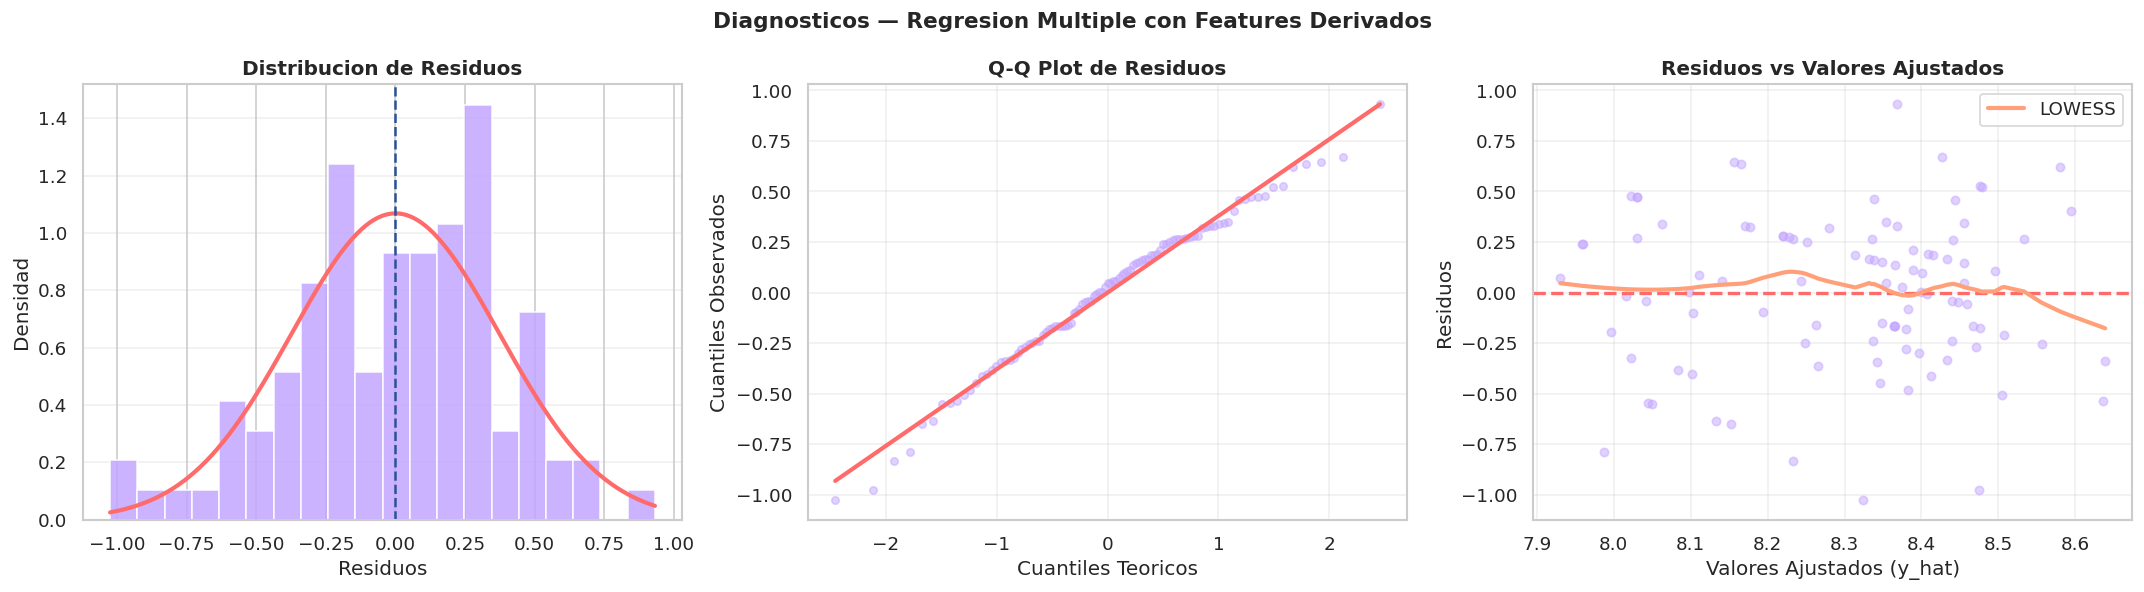


Test Shapiro-Wilk (Normalidad):
   p-value: 0.540796 -> OK No se rechaza normalidad

Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.475386 -> OK Homocedasticidad OK


In [25]:
# ── CELDA 24: Diagnosticos completos — modelo multiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnosticos — Regresion Multiple con Features Derivados',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos_m, bins=20, color='#c3a6ff', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribucion de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.5, s=20, color='#c3a6ff')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teoricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_m, residuos_m, alpha=0.5, s=25, color='#c3a6ff')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.4)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (y_hat)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png', dpi=150, bbox_inches='tight')
plt.show()

stat_sw_m, p_sw_m = stats.shapiro(residuos_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

sw_conclusion = 'OK No se rechaza normalidad' if p_sw_m > 0.05 else 'AVISO Se rechaza normalidad'
bp_conclusion = 'OK Homocedasticidad OK' if lm_p_m > 0.05 else 'AVISO Heterocedasticidad detectada'

print(f'\nTest Shapiro-Wilk (Normalidad):')
print(f'   p-value: {p_sw_m:.6f} -> {sw_conclusion}')
print(f'\nTest Breusch-Pagan (Homocedasticidad):')
print(f'   p-value: {lm_p_m:.6f} -> {bp_conclusion}')

## Fase 7: Comparacion de Modelos

In [26]:
# ── CELDA 25: Tabla comparativa ──────────────────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresion Simple', 'Regresion Multiple'],
    'Variables': ['log(recaudacion/duracion)',
                  'log(rec/dur) + duracion + anio + generos'],
    'n'        : [len(df_simple), len(df_multi)],
    'R2'       : [round(r2,   4), round(r2_m,   4)],
    'R2_Aj'    : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj,  4)],
    'RMSE'     : [round(rmse,  4), round(rmse_m,  4)],
    'MAE'      : [round(mae,   4), round(mae_m,   4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic,  2)],
})

print('=' * 80)
print('         COMPARACION DE MODELOS — ETL PELICULAS OMDB')
print('=' * 80)
print(comparacion.to_string(index=False))
print('=' * 80)
print('\nNota: AIC mas bajo = mejor equilibrio entre ajuste y parsimonia')
print('Nota: RMSE en puntos IMDb (escala 0-10)')

         COMPARACION DE MODELOS — ETL PELICULAS OMDB
            Modelo                                Variables  n      R2   R2_Aj   RMSE    MAE    AIC
  Regresion Simple                log(recaudacion/duracion) 99 -0.0437 -0.0101 0.3190 0.2496 108.80
Regresion Multiple log(rec/dur) + duracion + anio + generos 99 -0.1530  0.1002 0.3353 0.2725 103.92

Nota: AIC mas bajo = mejor equilibrio entre ajuste y parsimonia
Nota: RMSE en puntos IMDb (escala 0-10)


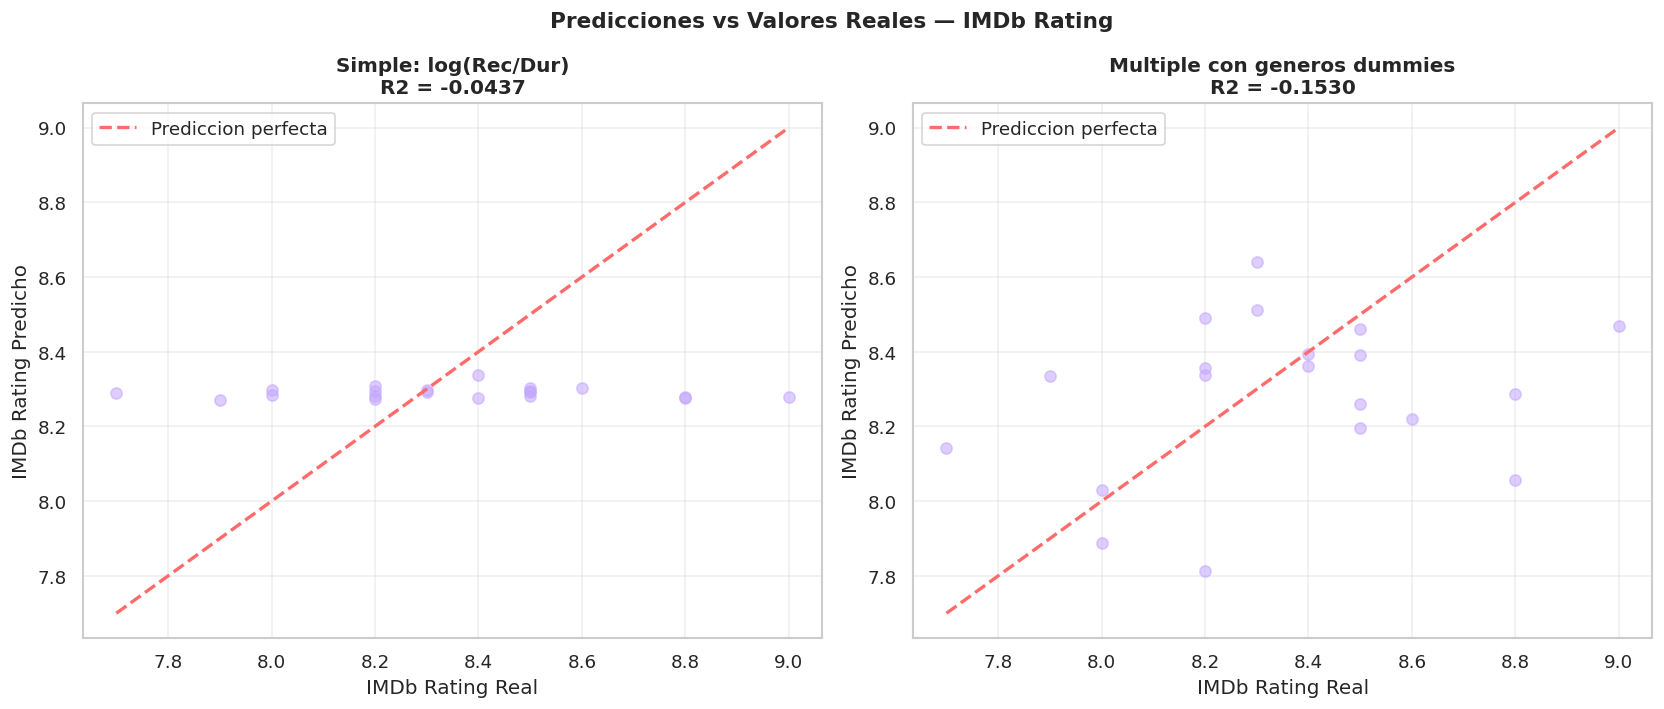

In [27]:
# ── CELDA 26: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales — IMDb Rating',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Simple: log(Rec/Dur)'),
    (y_test_m, y_pred_multi,  'Multiple con generos dummies'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.55, s=45, color='#c3a6ff')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Prediccion perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo}\nR2 = {r2_val:.4f}', fontweight='bold')
    ax.set_xlabel('IMDb Rating Real')
    ax.set_ylabel('IMDb Rating Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()

## Predictor interactivo con feature engineering

In [28]:
# ── CELDA 27: Predictor con modelo multiple + features ────────
# Cambia estos valores para predecir cualquier pelicula
nueva_pelicula = {
    'titulo':       'Mi Pelicula de Prueba',
    'duracion':     148,
    'anio':         2022,
    'recaudacion':  800_000_000,
    'generos':      ['es_drama', 'es_crime']
}

rec_por_min_val     = nueva_pelicula['recaudacion'] / nueva_pelicula['duracion']
rec_por_min_log_val = np.log10(rec_por_min_val)

generos_vector = {g: (1 if g in nueva_pelicula['generos'] else 0) for g in top_generos}

X_nueva = np.array([[
    rec_por_min_log_val,
    nueva_pelicula['duracion'],
    nueva_pelicula['anio'],
    *[generos_vector[g] for g in top_generos]
]])

pred = modelo_multi.predict(X_nueva)[0]
pred_clamp = np.clip(pred, 1.0, 10.0)

print(f'Pelicula         : {nueva_pelicula["titulo"]}')
print(f'Duracion         : {nueva_pelicula["duracion"]} min')
print(f'Anio             : {nueva_pelicula["anio"]}')
print(f'Recaudacion      : ${nueva_pelicula["recaudacion"]:,.0f}')
print(f'Rec/min          : ${rec_por_min_val:,.0f} USD/min (feature derivado)')
print(f'Generos          : {nueva_pelicula["generos"]}')
print(f'\nIMDb Rating predicho : {pred_clamp:.2f} / 10')

Pelicula         : Mi Pelicula de Prueba
Duracion         : 148 min
Anio             : 2022
Recaudacion      : $800,000,000
Rec/min          : $5,405,405 USD/min (feature derivado)
Generos          : ['es_drama', 'es_crime']

IMDb Rating predicho : 8.42 / 10
